# Decision Tree

A Decision Tree Algorithm is a non-parametric supervised learning algorithm used for both classification and regression tasks.
It operates by creating a model that predicts the value of a target variable based on several input variables.
The algorithm builds a tree-like model of decisions and their possible consequences, starting from a root node and branching out based on the outcomes of tests applied to the input variables.
These branches lead to internal nodes, which represent further decisions or tests, and eventually to leaf nodes, which represent the final outcomes or predictions.

In [1]:
#importing the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt

In [21]:
#Example data

data = {
    'Age' : [25, 45, 35, 50, 23, 37, 32, 28, 40, 27],
    'Income' : ['High', 'High', 'High', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium'],
    'Student' : ['No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No'],
    'Buys_Computer' : ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}

In [22]:
df = pd.DataFrame(data)

In [23]:
df

,Age,Income,Student,Buys_Computer
0,25,High,No,No
1,45,High,No,No
2,35,High,No,Yes
3,50,Medium,No,Yes
4,23,Low,Yes,Yes
5,37,Low,Yes,No
6,32,Low,Yes,Yes
7,28,Medium,Yes,No
8,40,Low,Yes,Yes
9,27,Medium,No,Yes


In [24]:
#Converting the categorical features to numeric 

df['Income'] = df['Income'].map({'Low':1, 'Medium':2, 'High':3})
df['Student'] = df['Student'].map({'Yes':1, 'No':0})
df['Buys_Computer'] = df['Buys_Computer'].map({'Yes':1, 'No':0})

In [25]:
df

,Age,Income,Student,Buys_Computer
0,25,3,0,0
1,45,3,0,0
2,35,3,0,1
3,50,2,0,1
4,23,1,1,1
5,37,1,1,0
6,32,1,1,1
7,28,2,1,0
8,40,1,1,1
9,27,2,0,1


In [26]:
#Independent variables (features) and Dependent variables (target)

X = df[['Age', 'Income', 'Student']]
Y = df['Buys_Computer']

In [27]:
X,Y

(   Age  Income  Student
 0   25       3        0
 1   45       3        0
 2   35       3        0
 3   50       2        0
 4   23       1        1
 5   37       1        1
 6   32       1        1
 7   28       2        1
 8   40       1        1
 9   27       2        0,
 0    0
 1    0
 2    1
 3    1
 4    1
 5    0
 6    1
 7    0
 8    1
 9    1
 Name: Buys_Computer, dtype: int64)

In [36]:
#Splitting the data into training and testing sets

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 0)

In [37]:
model = DecisionTreeClassifier(criterion='gini', max_depth = 3, random_state=0)
model

DecisionTreeClassifier(max_depth=3, random_state=0)

In [39]:
model.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [40]:
Y_pred = model.predict(X_test)

In [42]:
#Making predictions

Y_pred

array([0, 0], dtype=int64)

In [58]:
# Evaluating the model

Accuracy = accuracy_score(Y_test, Y_pred)
class_report = classification_report(Y_test, Y_pred)
Conf_Matrix = confusion_matrix(Y_test, Y_pred)

print(f"accuracy_score: {Accuracy}")
print(f"classification_report:\n {class_report}")
print(f"confusion_matrix:\n {Conf_Matrix}")

accuracy_score: 0.0
classification_report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0

confusion_matrix:
 [[0 0]
 [2 0]]


C:\Users\jetti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jetti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jetti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

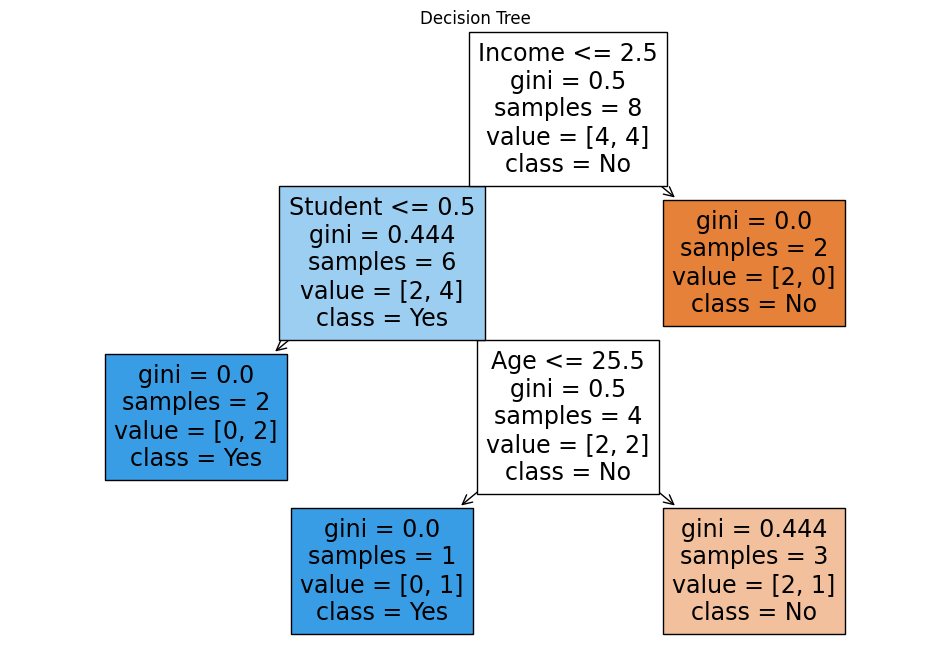

In [60]:
#Plotting the decision tree

plt.figure(figsize=(12,8))
plot_tree(model, feature_names=['Age', 'Income', 'Student'],
                 class_names = ['No', 'Yes'], filled=True)
plt.title('Decision Tree')
plt.show()

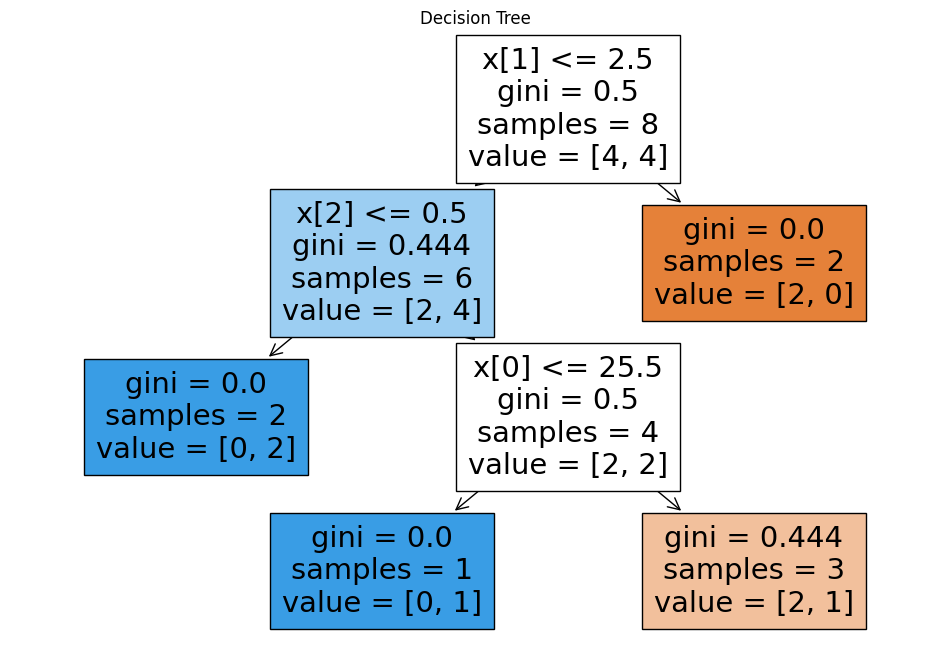

In [61]:
#Plotting the decision tree

plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.title('Decision Tree')
plt.show()